<div style="border:1px solid black; padding:10px 10px;">
    <strong>CIVIL-321 "Modélisation Numérique des Solides et Structures"</strong><br/><br/>
    <span style="text-decoration:underline;font-weight:bold;">Comment utiliser ce Jupyter Notebook?
    </span><br/><br/>
    Ce <strong>Notebook</strong> est constitué de cellules de texte et de cellule de code. Les cellules de codes doivent être  <strong>executées</strong> pour voir le résultat du programme. Certaines cellules doivent être remplies par vos soins. Pour exécuter une cellule, cliquez dessus simplement et ensuite cliquez sur le bouton "play" (<span style="font: bold 12px/30px Arial, serif;">&#9658;</span>) dans la barre de menu au dessus du notebook. Vous pouvez aussi taper la combinaison de touches <code>shift + enter</code>. Il est important d'éxécuter les cellules de code en respectant leur ordre d'arrivée dans le notebook.
</div>

On vous encourage à poser vos questions et donner votre feedback sur ce notebook sur la plateforme ED Discussion du cours accessible en cliquant sur ce bouton:
 
 
 
<div class="container" >
        <a href="https://edstem.org/eu/courses/409/discussion?category=Exercices">
            <button class="btn btn-primary btn-lg">Ed Discussion</button>
        </a>
</div>

In [1]:
from utils import *

## Exercice 1: Énergie de déformation et minimisation (Python)

En méthode des éléments finis, l'énergie élastique (ou énergie de déformation) totale d'un système discret s'écrit de manière beaucoup plus efficace sous forme matricielle :
$$E_\text{el} = \frac{1}{2} \mathbf{u}^\top \mathbf{K} \mathbf{u}$$

L'énergie potentielle totale du système, qui prend en compte le travail des forces extérieures, s'écrit quant à elle :
$$\Pi = \frac{1}{2} \mathbf{u}^\top \mathbf{K} \mathbf{u} - \mathbf{u}^\top \mathbf{F}$$

**1. Factorisation du code de l'Exercice 2 du notebook Exercice_01_solution.ipynb**
Pour étudier cette énergie facilement, nous allons d'abord créer une fonction qui génère notre système pour un nombre $n$ de ressorts donné. 

En reprenant le code que vous avez écrit à la question 5 de l'Exercice 2 du notebook **Exercice_01_solution.ipynb**, complétez la fonction `build_and_solve(n)` ci-dessous pour qu'elle assemble les matrices, résolve le système, et retourne le vecteur déplacement $\mathbf{u}$, la matrice de rigidité $\mathbf{K}$ et le vecteur force $\mathbf{F}$.

*Note: La rigidité totale du système est $k=1$ et la somme des forces, $f=1$*

In [2]:
def build_and_solve(n):
    k = 1
    f = 1
    # ... Insérez ici votre code d'assemblage et de résolution de l'Exercice 2 ...
    
    # return u, K, F

In [3]:
# SolutionToRemove
def build_and_solve(n):
    k = 1
    f = 1
    kl = n * k
    kloc = kl * np.array([[1, -1], [-1, 1]])

    K = np.zeros((n+1, n+1))

    # Assemblage
    for e in range(n):
        for i in range(2):
            for j in range(2):
                K[e+i, e+j] += kloc[i, j]
    
    # Vecteur force
    F = np.ones(n+1) * f / n
            
    # Conditions limites et résolution
    noeuds_libres = range(1, n)
    K_libre = K[noeuds_libres, :][:, noeuds_libres]
    F_libre = F[noeuds_libres]

    u = np.zeros(n+1)
    u[noeuds_libres] = np.linalg.solve(K_libre, F_libre)
    
    return u, K, F

**2. Calcul matriciel des énergies**
En utilisant Numpy, écrivez une fonction `compute_energies(u, K, F)` qui calcule et retourne l'énergie élastique $E_\text{el}$ ainsi que l'énergie potentielle totale $\Pi$. 
*Indice : L'opérateur `@` permet de faire des multiplications matricielles en Python et l'opérateur `.T` permet de transposer vecteurs et matrices.*

In [4]:
# SolutionToRemove
def compute_energies(u, K, F):
    # L'énergie élastique: 0.5 * u^T * K * u
    E_el = 0.5 * u.T @ K @ u
    
    # L'énergie potentielle totale: E_el - u^T * F
    Pi = E_el - (u.T @ F)
    
    return E_el, Pi

**3. Convergence de l'énergie de déformation**
L'énergie de déformation analytique exacte de cette barre continue est $E_\text{exact} = \frac{f^2}{24 k}$.

Grâce à vos deux fonctions, calculez l'énergie élastique numérique pour différents nombres de ressorts : $n \in [2, 4, 8, 16, 32, 64]$. 
Tracez l'évolution de l'erreur relative $\left| \frac{E_\text{el} - E_\text{exact}}{E_\text{exact}} \right|$ en fonction de $n$ (utilisez une échelle logarithmique pour l'axe X et Y).

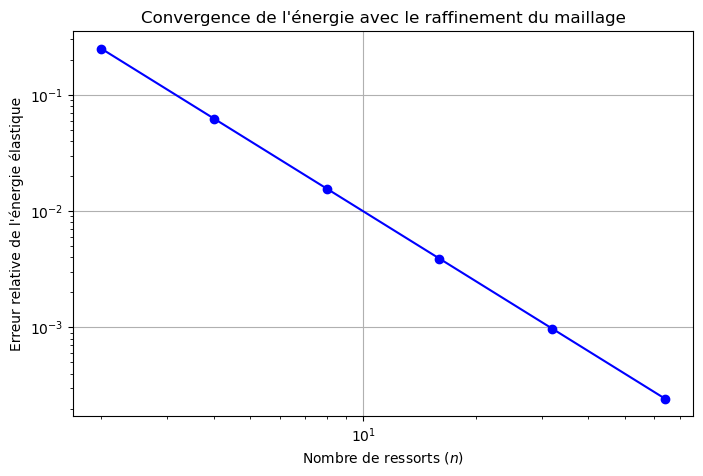

In [5]:
# SolutionToRemove
import matplotlib.pyplot as plt

n_values = [2, 4, 8, 16, 32, 64]
errors = []

f = 1
k = 1
E_exact = (f**2) / (24 * k)

for n in n_values:
    # 1. Génération et résolution grâce à la fonction factorisée
    u, K, F = build_and_solve(n)
    
    # 2. Calcul des énergies
    E_el, _ = compute_energies(u, K, F)
    
    # 3. Calcul de l'erreur
    error = abs(E_el - E_exact) / E_exact
    errors.append(error)

# Affichage graphique
plt.figure(figsize=(8, 5))
plt.plot(n_values, errors, marker='o', linestyle='-', color='b')
plt.xlabel('Nombre de ressorts ($n$)')
plt.ylabel("Erreur relative de l'énergie élastique")
plt.title("Convergence de l'énergie avec le raffinement du maillage")
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.show()

**4. Visualisation du principe de minimisation**
La solution d'équilibre $\mathbf{u}_\text{eq}$ que vous venez de calculer est par définition celle qui minimise l'énergie potentielle totale $\Pi$. Vérifions-le !

**a. Exploration par variation linéaire**
**Objectif :** Observer la convexité de l'énergie potentielle totale le long d'une "coupe" passant par la solution d'équilibre.

1. À partir de la solution d'équilibre $\mathbf{u}_\text{eq}$ obtenue pour $n=4$, créez une famille de déplacements virtuels de forme $\mathbf{u}(\alpha) = (1-\alpha) \mathbf{u}_\text{eq}$ ou $\alpha$ est un scalaire variant de $-1$ à $1$.
-  *Note: Puisque $\mathbf{u}_\text{eq}$ satisfait déjà les conditions aux limites (déplacements nuls aux appuis), $\mathbf{u}(\alpha)$ les satisfait aussi.*
2. Pour chaque valeur de $\alpha$, calculer l'énergie potentielle totale $\Pi(\alpha)$.
3. Tracer la courbe de l'énergie potentielle totale en fonction de $\alpha$

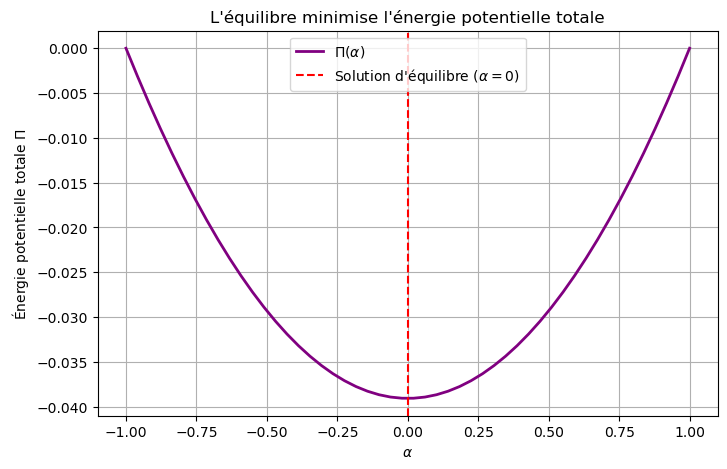

In [6]:
# SolutionToRemove
# Récupération du système à l'équilibre
u_eq, K, F = build_and_solve(n=4)

alpha_values = np.linspace(-1, 1, 50)
Pi_uniforme = []
for alpha in alpha_values:
    u_test = (1 - alpha) * u_eq
    _, Pi = compute_energies(u_test, K, F)
    Pi_uniforme.append(Pi)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alpha_values, Pi_uniforme, label=r"$\Pi(\alpha)$", color='purple', linewidth=2)
ax.axvline(x=0, color='r', linestyle='--', label=r"Solution d'équilibre ($\alpha = 0$)")
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'Énergie potentielle totale $\Pi$')
ax.set_title("L'équilibre minimise l'énergie potentielle totale")
ax.legend()
plt.grid(True)
plt.show()

**b. Exploration par perturbations aléatoires**
**Objectif :** Démontrer que l'équilibre est un minimum global en testant des directions de déplacement aléatoires.

1. Générez un grand nombre (ex: 500) de vecteurs de déplacements test $\mathbf{u}_\text{test}=\mathbf{u}_\text{eq}+\delta\mathbf{u}$
- *Note: La perturbation $\delta\mathbf{u}$ doit être cinématiquement admissible. Cela signifie que vous devez générer du bruit aléatoire uniquement pour les nœuds libres (ceux qui ne sont pas fixés aux appuis). Les composantes de $\delta\mathbf{u}$ correspondant aux nœuds fixes doivent rester strictement nulles.*
2. Pour chaque test, calculer la distance relative à l'équilibre: $\epsilon=\frac{||u - u_{eq}||}{||u_{eq}||}$ ainsi que l'énergie potentielle totale $\Pi$.
3. Tracer un nuage de points (scatter plot) représentant $\Pi$ en fonction de $\epsilon$.
4. Vérifiez qu'aucun point du nuage ne se situe en dessous de la valeur de l'énergie d'équilibre.

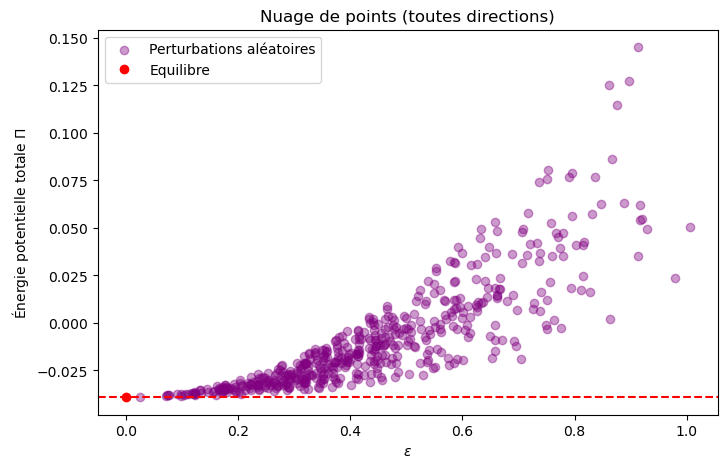

In [7]:
# SolutionToRemove
noeuds_libres = range(1, len(u_eq) - 1)

n_samples = 500
dist_rand = []
Pi_rand = []

for _ in range(n_samples):
    # Perturbation uniquement sur les degrés de liberté libres
    noise = np.random.randn(len(noeuds_libres)) * 0.05
    u_test = u_eq.copy()
    u_test[noeuds_libres] += noise # On laisse les bords à 0
    
    dist = np.linalg.norm(u_test - u_eq) / np.linalg.norm(u_eq) # Distance relative à l'équilibre
    _, Pi = compute_energies(u_test, K, F)
    dist_rand.append(dist)
    Pi_rand.append(Pi)

# Affichage
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(dist_rand, Pi_rand, alpha=0.4, color='purple', label='Perturbations aléatoires')
ax.plot(0, compute_energies(u_eq, K, F)[1], 'ro', label='Equilibre')
ax.axhline(y=compute_energies(u_eq, K, F)[1], color='r', linestyle='--')
ax.set_ylabel(r'Énergie potentielle totale $\Pi$')
ax.set_xlabel(r'$\epsilon$')
ax.set_title("Nuage de points (toutes directions)")
ax.legend()
plt.show()

# 💬 Votre retour d'expérience

Votre avis nous aide à améliorer les prochains notebooks ! N'hésitez pas à nous partager :

- Ce que vous avez aimé (clarté, sujet, etc.)
- Ce qui a été difficile (points bloquants, consignes floues)
- Le temps passé sur l'exercice
- Toute suggestion pour la suite

Note : Double-cliquez sur cette cellule pour écrire votre commentaire et **valider la cellule** pour nous envoyer votre réponse.